en este archivo voy a hacer los analisis principales

In [21]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline

In [22]:
# Sigmoid fit function: 

def sloped_sigmoid(t, m, c, L, k, t0):
    exponent = np.clip(k * (t - t0), -500, 500) #creo que no es necesario el clipeo lol
    return L + (m * t + c - L) / (1 + np.exp(exponent))

# El fit ensi:

def sigmoid_fit(t, T, W, chop=0):

    mask = t > chop # mascara para cortar los segundos 
    t_chopped = t[mask]
    T_chopped = T[mask]
    W_chopped = W[mask]

    initial_guess = [0.01, 0, max(T_chopped), 1, np.median(t_chopped)]
    params, _ = curve_fit(sloped_sigmoid, t_chopped, T_chopped, p0=initial_guess,maxfev=10000)

    plt.figure(figsize=(10, 6))
    plt.scatter(t, T, label='Data', color='blue', s=10)
    plt.plot(t_chopped, sloped_sigmoid(t_chopped, *params), label='Sigmoid Fit', color='red')
    plt.legend()
    plt.show()


    return np.linspace(min(t_chopped), max(t_chopped), 1000) - np.min(t_chopped), sloped_sigmoid(np.linspace(min(t_chopped), max(t_chopped), 1000), *params), W_chopped

In [ ]:
def boiling_curve(t_array, T_array_C,dT_dt, mass_g, area_cm2, material='cu'):
   
    # Material properties: { 'material_name': (molar_mass_g_mol, theta_D) }
    properties = {
        'cu': (63.546, 315.0),
        'al': (26.98, 428.0) 
    }
    
    T_sat_K = 77.36 # NLA2 o algo asi jaja

    material = material.lower()

    molar_mass_g_mol, theta_D = properties[material]
    
    n_moles = mass_g / molar_mass_g_mol

    R = 8.314  # en J/(mol*K)

    # theta_E = 0.77 * theta_D 

    a, b, c = 0.77, 0.26, 9.17
    
    t_array = np.array(t_array)
    T_K = np.array(T_array_C) + 273.15 #tiene q estar en kelvin

    theta_E = theta_D * (a + b * np.exp(-c * T_K / theta_D))  

    
    cooling_rate = -dT_dt
    
    term1 = 3 * R * (theta_E / T_K)**2
    term2 = np.exp(theta_E / T_K) / (np.exp(theta_E / T_K) - 1)**2
    Cv_T = term1 * term2
    
    Q_dot_A = (n_moles / area_cm2) * Cv_T * cooling_rate

    delta_T = T_K - T_sat_K
    valid = (delta_T > 0) & (Q_dot_A > 0)
    
    return delta_T[valid], Q_dot_A[valid]

# Las dos mediciones de C0.

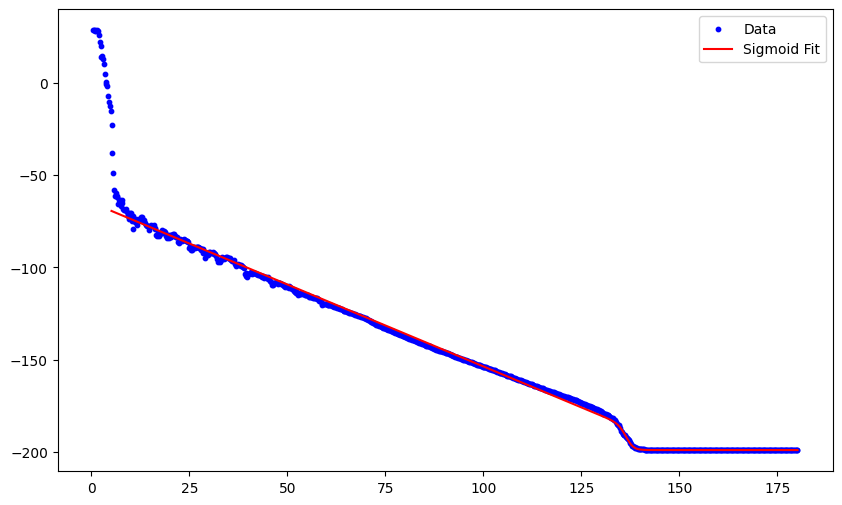

In [513]:
df = pd.read_csv('data_clean/C0.csv')
t,T,W = sigmoid_fit(df['t'], df['T'], df['W'] ,chop=5)

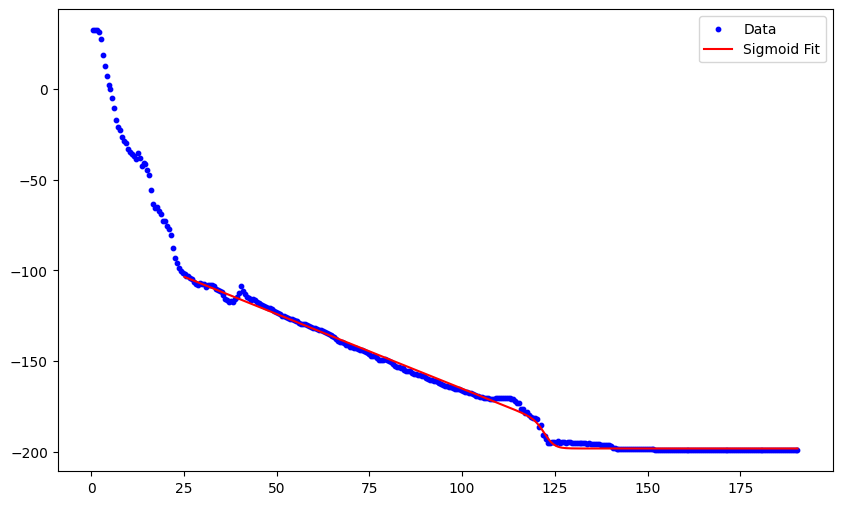

In [514]:
Delta_t, Q_dot_A = boiling_curve(t, T, dT_dt= np.gradient(T),mass_g=10, area_cm2=1, material='cu')

df = pd.read_csv('data_clean/C0_2.csv')
t2,T2,W2 = sigmoid_fit(df['t'], df['T'], df['W'] ,chop=25)

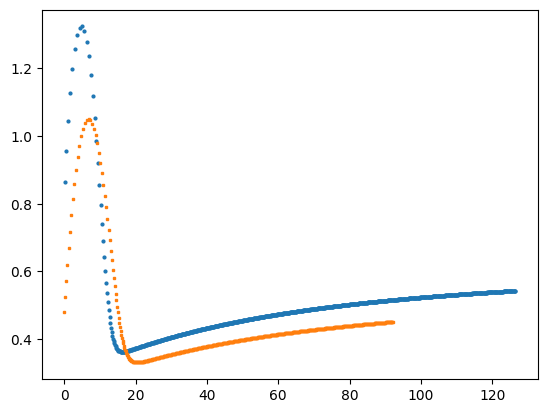

In [516]:
Delta_t2, Q_dot_A2 = boiling_curve(t2, T2,dT_dt= np.gradient(T2),mass_g=10, area_cm2=1, material='cu')

plt.plot(Delta_t, Q_dot_A, label='C0 Sample 1', marker='o', linestyle='', markersize=2)
plt.plot(Delta_t2, Q_dot_A2, label='C0 Sample 2', marker='s', linestyle='', markersize=2)

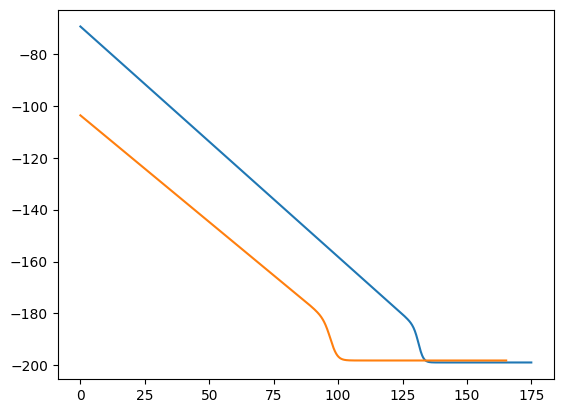

In [517]:
plt.plot(t,T)
plt.plot(t2,T2)

No hay mucho que sacar de acá. el primero habia salido medio mal e igual depende de donde cropees la data. next.


# Aluminio vs cobre

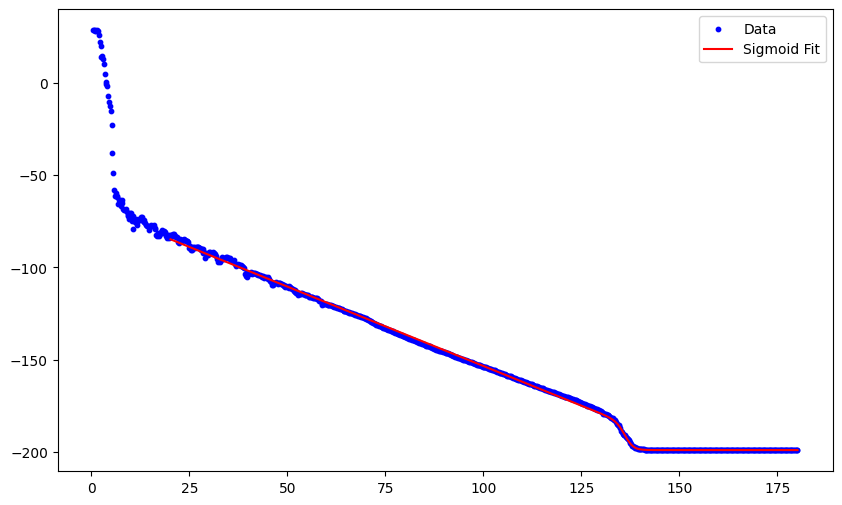

In [382]:
df = pd.read_csv('data_clean/C0.csv')
t,T,W = sigmoid_fit(df['t'], df['T'], df['W'] ,chop=20)
Delta_t, Q_dot_A = boiling_curve(t, T, mass_g=164.88, area_cm2=37.7, material='cu',plot=False)


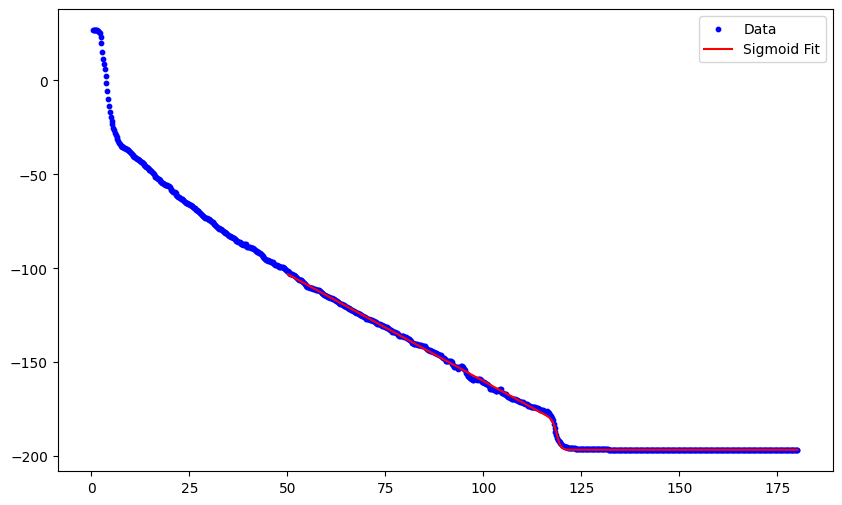

In [383]:
df = pd.read_csv('data_clean/A0.csv')

t_al , T_al, W_al = sigmoid_fit(df['t'], df['T'], df['W'] ,chop=50)

In [384]:
Delta_t_al, Q_dot_A_al = boiling_curve(t_al, T_al, mass_g=66, area_cm2=50, material='cu',plot=False)


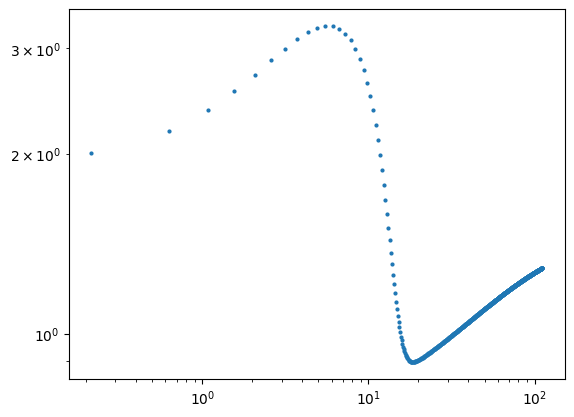

In [385]:
plt.loglog(Delta_t, Q_dot_A, label='C0 Sample 1', marker='o', linestyle='', markersize=2)


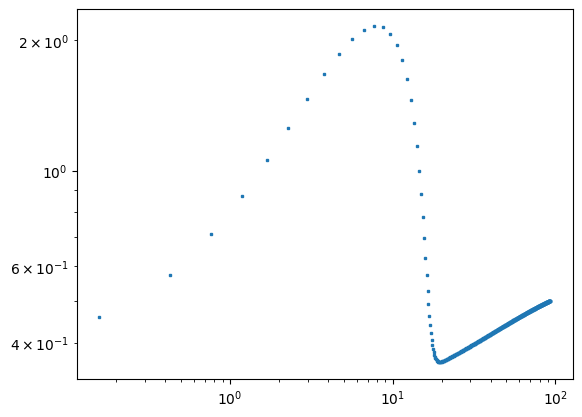

In [386]:
plt.loglog(Delta_t_al, Q_dot_A_al, label='A0 Sample 1', marker='s', linestyle='', markersize=2)

# Distintos chops para aluminio
esto lo hago porque me queda la duda de si cambia mucho la curva dependiendo de cuanto chopee la data

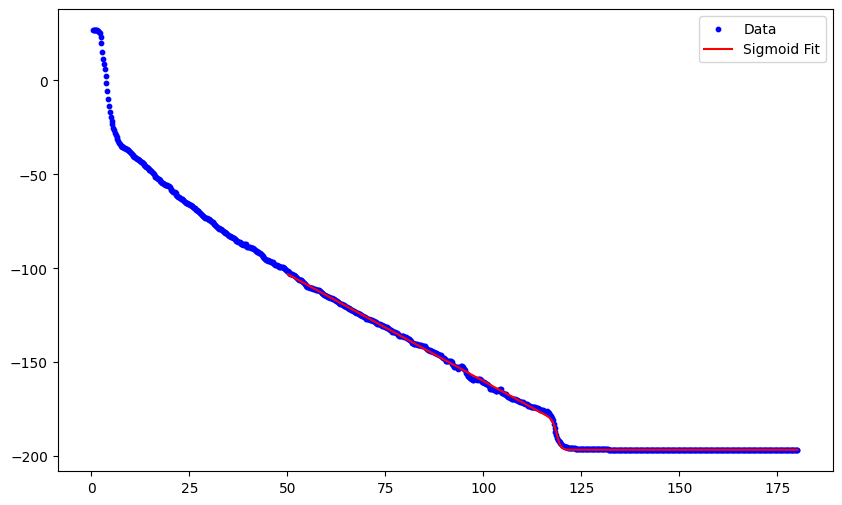

In [524]:
df = pd.read_csv('data_clean/A0.csv')

t50 , T50, W50 = sigmoid_fit(df['t'], df['T'], df['W'] ,chop=50)

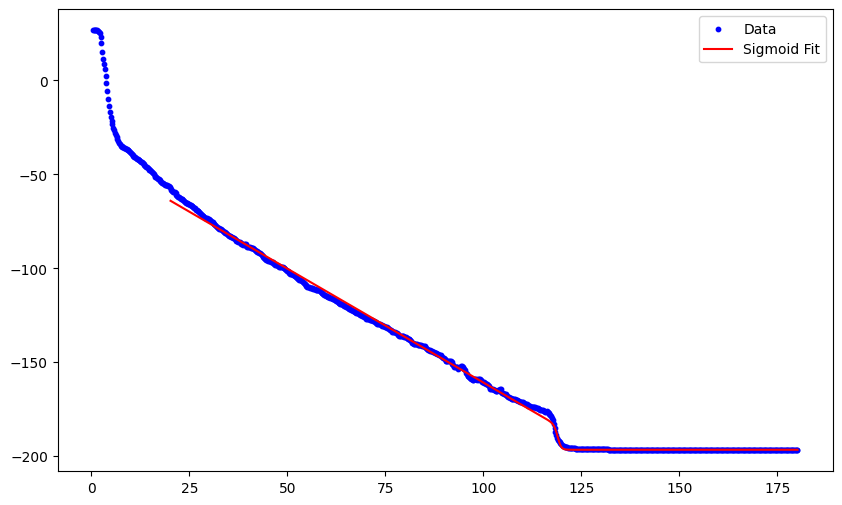

In [388]:
t20 , T20, W20 = sigmoid_fit(df['t'], df['T'], df['W'] ,chop=20)

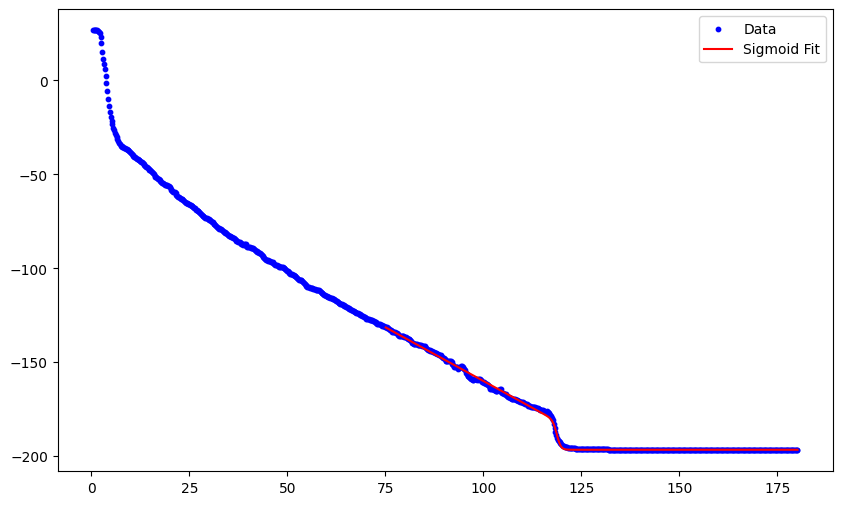

In [389]:
t75 , T75, W75 = sigmoid_fit(df['t'], df['T'], df['W'] ,chop=75)

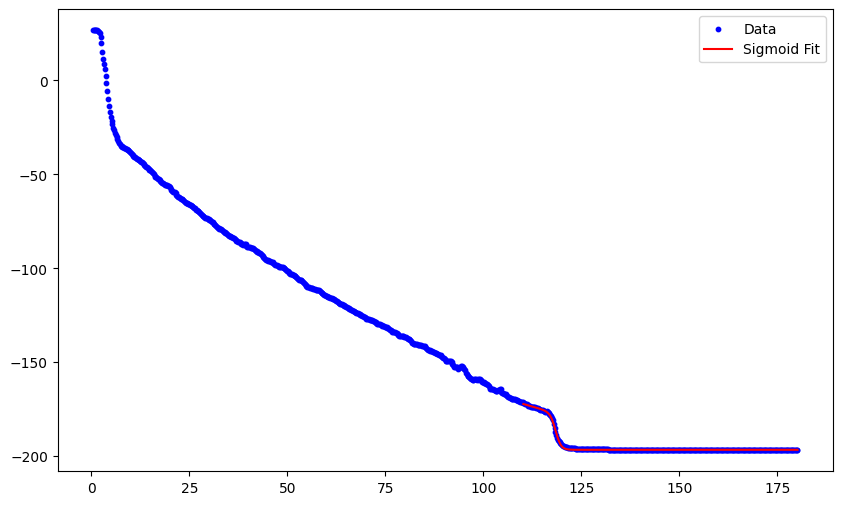

In [390]:
t110 , T110, W110 = sigmoid_fit(df['t'], df['T'], df['W'] ,chop=110)

In [391]:
delta_t50, Q_dot_A50 = boiling_curve(t50, T50, mass_g=66, area_cm2=50, material='cu',plot=False)
delta_t20, Q_dot_A20 = boiling_curve(t20, T20, mass_g=66, area_cm2=50, material='cu',plot=False)
delta_t75, Q_dot_A75 = boiling_curve(t75, T75, mass_g=66, area_cm2=50, material='cu',plot=False)
delta_t100, Q_dot_A100 = boiling_curve(t100, T100, mass_g=66, area_cm2=50, material='cu',plot=False)
delta_t110, Q_dot_A110 = boiling_curve(t110, T110, mass_g=66, area_cm2=50, material='cu',plot=False)

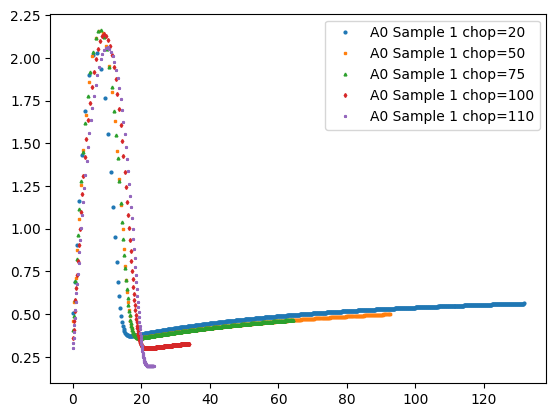

In [392]:
plt.plot(delta_t20, Q_dot_A20, label='A0 Sample 1 chop=20', marker='o', linestyle='', markersize=2)
plt.plot(delta_t50, Q_dot_A50, label='A0 Sample 1 chop=50', marker='s', linestyle='', markersize=2)
plt.plot(delta_t75, Q_dot_A75, label='A0 Sample 1 chop=75', marker='^', linestyle='', markersize=2)
plt.plot(delta_t100, Q_dot_A100, label='A0 Sample 1 chop=100', marker='d', linestyle='', markersize=2)
plt.plot(delta_t110, Q_dot_A110, label='A0 Sample 1 chop=110', marker='*', linestyle='', markersize=2)
plt.legend()

In [393]:
def analyze_peak(x, y):
    """Calculates peak position, peak height, and FWHM."""
    # 1. Find the Peak
    max_idx = np.argmax(y)
    peak_x = x[max_idx]
    peak_y = y[max_idx]
    
    # 2. Find the FWHM
    half_max = peak_y / 2.0
    
    # Find indices where the y-value crosses the half_max threshold
    # np.sign gives 1 for positive, -1 for negative. np.diff finds the flips.
    crossings = np.where(np.diff(np.sign(y - half_max)))[0]
    
    if len(crossings) >= 2:
        # Interpolate exact X for the left crossing
        idx_L = crossings[0]
        x1, x2 = x[idx_L], x[idx_L+1]
        y1, y2 = y[idx_L], y[idx_L+1]
        left_x = x1 + (half_max - y1) * (x2 - x1) / (y2 - y1)
        
        # Interpolate exact X for the right crossing
        idx_R = crossings[-1] # Take the last crossing for the right side
        x3, x4 = x[idx_R], x[idx_R+1]
        y3, y4 = y[idx_R], y[idx_R+1]
        right_x = x3 + (half_max - y3) * (x4 - x3) / (y4 - y3)
        
        fwhm = right_x - left_x
    else:
        fwhm = np.nan # Just in case the curve doesn't drop down to half_max
        
    return peak_x, peak_y, fwhm

# --- How to use it with your arrays ---

datasets = {
    'chop=20': (delta_t20, Q_dot_A20),
    'chop=50': (delta_t50, Q_dot_A50),
    'chop=75': (delta_t75, Q_dot_A75),
    'chop=100': (delta_t100, Q_dot_A100),
    'chop=110': (delta_t110, Q_dot_A110)
}

print(f"{'Dataset':<12} | {'Peak X (Δt)':<12} | {'Peak Y (Q_dot)':<14} | {'FWHM':<12}")
print("-" * 58)

for name, (x_arr, y_arr) in datasets.items():
    peak_x, peak_y, fwhm = analyze_peak(x_arr, y_arr)
    print(f"{name:<12} | {peak_x:<12.4f} | {peak_y:<14.4f} | {fwhm:<12.4f}")

Dataset      | Peak X (Δt)  | Peak Y (Q_dot) | FWHM        
----------------------------------------------------------
chop=20      | 7.0573       | 2.0295         | -10.7759    
chop=50      | 7.6618       | 2.1605         | -12.4794    
chop=75      | 8.2702       | 2.1609         | -12.4594    
chop=100     | 9.0531       | 2.1376         | -13.9265    
chop=110     | 10.1353      | 2.0621         | -14.8013    


# Savgol por partes para aluminio

In [4]:
df = pd.read_csv('data_clean/A1.csv')
t, T , W = df['t'].values, df['T'].values, df['W'].values

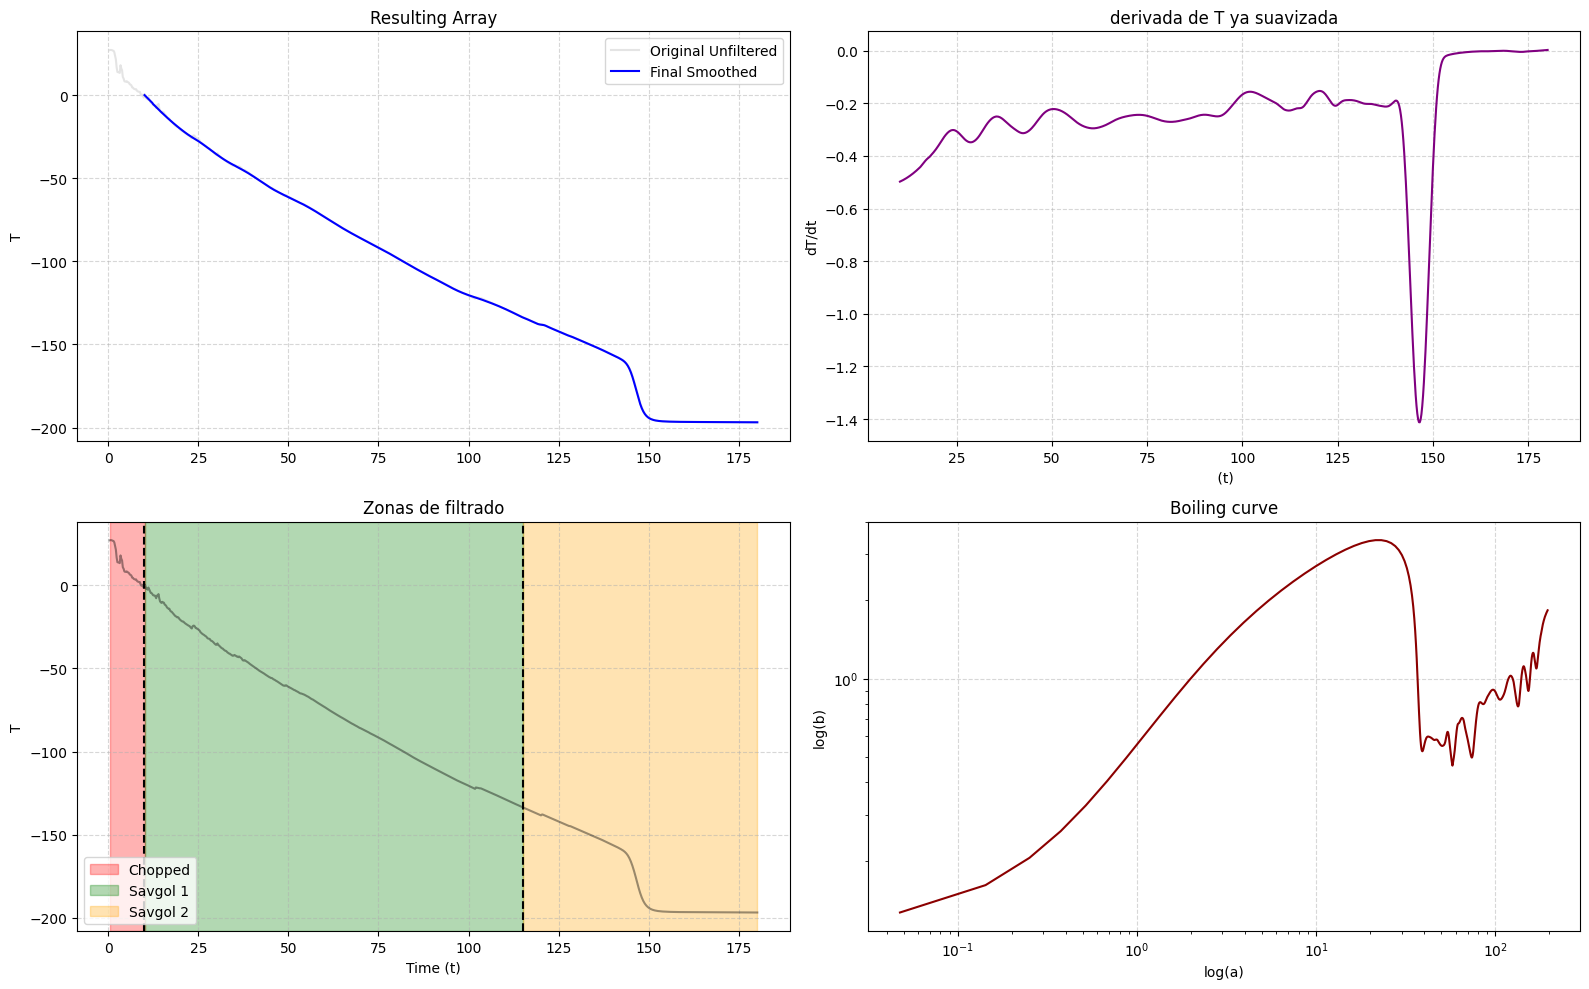

In [5]:
from scipy.signal import savgol_filter

def apply_piecewise_savgol(t, T, chop_time=5.0, split_time=115.0, 
                           sg1_params=(51, 3), sg2_params=(11, 2), 
                           global_smooth_params=(31, 3)):
    """Applies piecewise Savitzky-Golay filters and a global smoothing pass."""
    idx_chop = np.searchsorted(t, chop_time)
    idx_split = np.searchsorted(t, split_time)
    
    t_seg1, T_seg1 = t[idx_chop:idx_split], T[idx_chop:idx_split]
    t_seg2, T_seg2 = t[idx_split:], T[idx_split:]
    
    T_seg1_filt = savgol_filter(T_seg1, sg1_params[0], sg1_params[1])
    T_seg2_filt = savgol_filter(T_seg2, sg2_params[0], sg2_params[1])
    
    t_final = np.concatenate((t_seg1, t_seg2))
    T_final = np.concatenate((T_seg1_filt, T_seg2_filt))
    
    if global_smooth_params:
        T_final = savgol_filter(T_final, global_smooth_params[0], global_smooth_params[1])
        
    return t_final, T_final, idx_chop, idx_split

def plot_comprehensive_analysis(t, T, t_final, T_final, i_chop, i_split, chop_time, split_time, a, b, dT_dt):
    """Plots the resulting array, filtering zones, derivative, and boiling curve."""
    dT_dt = dT_dt

    fig, axs = plt.subplots(2, 2, figsize=(16, 10))
    ax_top_left, ax_bot_left, ax_top_right, ax_bot_right = axs[0, 0], axs[1, 0], axs[0, 1], axs[1, 1]

    # --- TOP LEFT: Final processed array ---
    ax_top_left.plot(t, T, color='lightgray', label='Original Unfiltered', alpha=0.6)
    ax_top_left.plot(t_final, T_final, color='blue', label='Final Smoothed', linewidth=1.5)
    ax_top_left.set_ylabel('T')
    ax_top_left.set_title('Resulting Array')
    ax_top_left.legend()
    ax_top_left.grid(True, linestyle='--', alpha=0.5)

    # --- BOTTOM LEFT: Segmentation Visualization ---
    ax_bot_left.plot(t, T, color='black', alpha=0.4)
    ax_bot_left.axvspan(t[0], t[i_chop], color='red', alpha=0.3, label='Chopped')
    ax_bot_left.axvspan(t[i_chop], t[i_split], color='green', alpha=0.3, label='Savgol 1')
    ax_bot_left.axvspan(t[i_split], t[-1], color='orange', alpha=0.3, label='Savgol 2')

    for line in [chop_time, split_time]:
        ax_bot_left.axvline(x=line, color='black', linestyle='--', linewidth=1.5)

    ax_bot_left.set_xlabel('Time (t)')
    ax_bot_left.set_ylabel('T')
    ax_bot_left.set_title('Zonas de filtrado')
    ax_bot_left.legend(loc='lower left')
    ax_bot_left.grid(True, linestyle='--', alpha=0.5)
    ax_top_left.sharex(ax_bot_left)

    # --- TOP RIGHT: Derivative Plot ---
    ax_top_right.plot(t_final, dT_dt, color='purple', linewidth=1.5)
    ax_top_right.set_xlabel(' (t)')
    ax_top_right.set_ylabel('dT/dt')
    ax_top_right.set_title('derivada de T ya suavizada')
    ax_top_right.grid(True, linestyle='--', alpha=0.5)

    # --- BOTTOM RIGHT: Boiling Curve ---
    ax_bot_right.loglog(a, b, color='darkred', linewidth=1.5)
    ax_bot_right.set_xlabel('log(a)')
    ax_bot_right.set_ylabel('log(b)')
    ax_bot_right.set_title('Boiling curve')
    ax_bot_right.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

chop_t = 10.0
split_t = 115.0



# 1. Filter the data
t_final, T_final, i_chop, i_split = apply_piecewise_savgol(
    t, T, chop_time=chop_t, split_time=split_t,
    sg1_params=(111, 4), sg2_params=(13, 2), global_smooth_params=(22, 4)
)

dT_dt = savgol_filter(T_final,51,3,deriv=1)


#2. Get boiling curve components
a, b = boiling_curve(t_final, T_final, dT_dt, mass_g=10, area_cm2=1, material='cu')

# 3. Plot everything via the new function
plot_comprehensive_analysis(t, T, t_final, T_final, i_chop, i_split, chop_t, split_t, a, b, dT_dt)

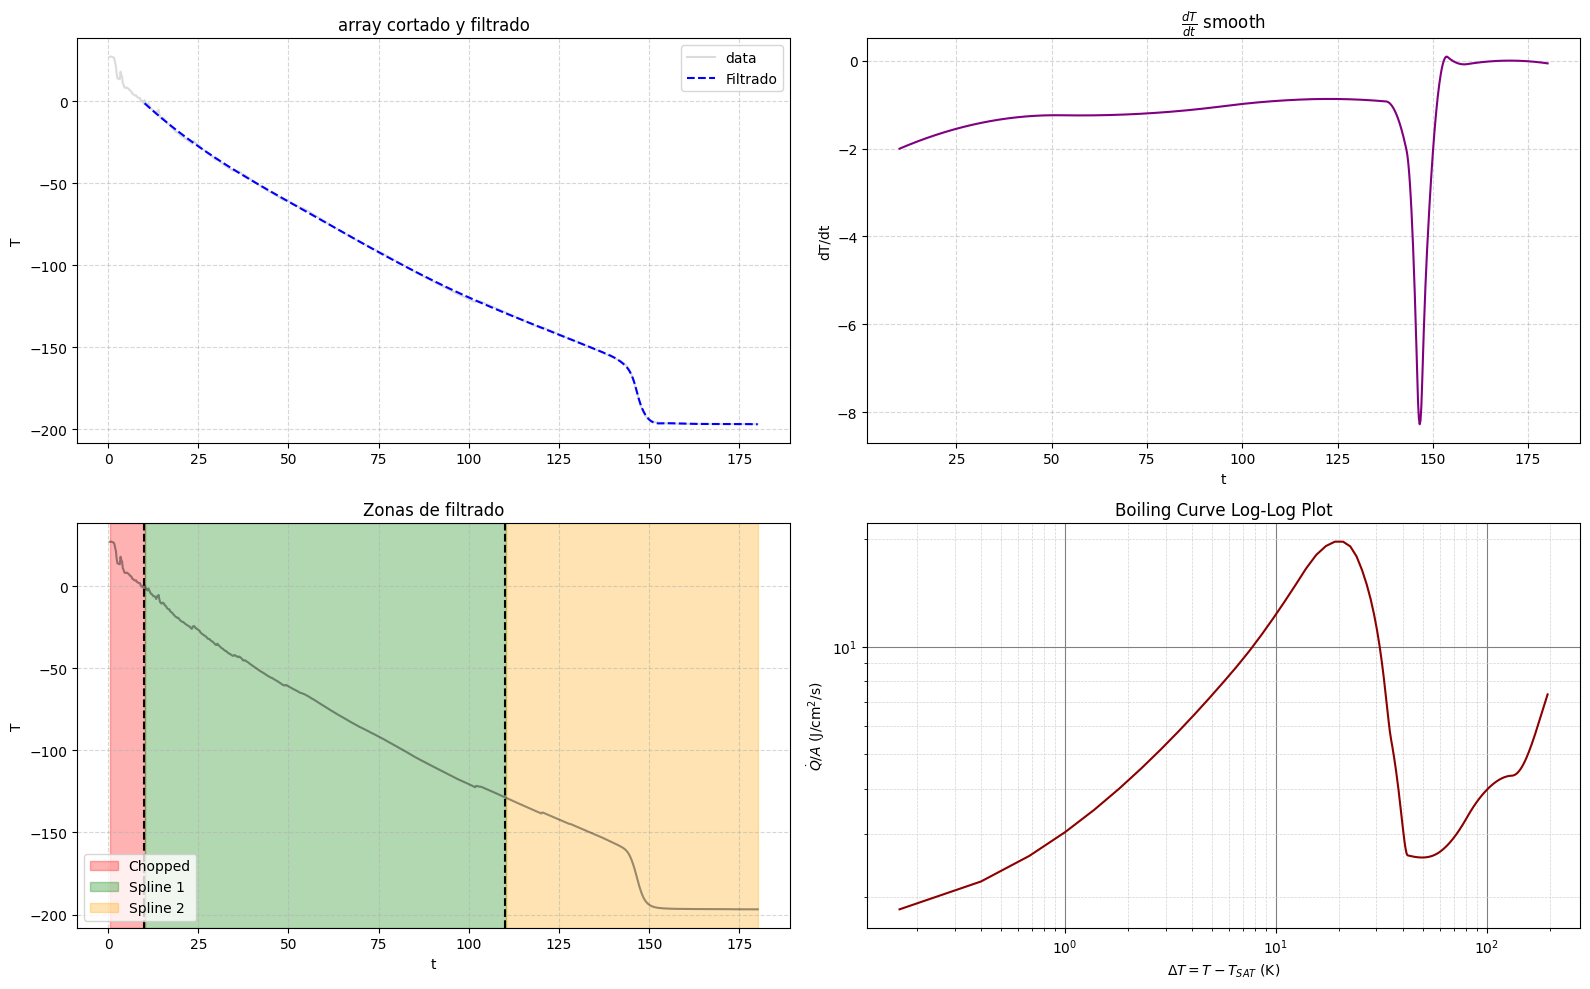

In [6]:
from scipy.interpolate import UnivariateSpline

def apply_piecewise_spline(t, T, chop_time=5.0, split_time=115.0, 
                           s1=5000, s2=1000, global_s=2000, k=3):
    """Applies piecewise Univariate splines and a global smoothing pass."""
    idx_chop = np.searchsorted(t, chop_time)
    idx_split = np.searchsorted(t, split_time)
    
    t_seg1, T_seg1 = t[idx_chop:idx_split], T[idx_chop:idx_split]
    t_seg2, T_seg2 = t[idx_split:], T[idx_split:]
    
    # Apply individual splines (k=3 is cubic). 
    # 's' is the smoothing factor. You will need to tweak these!
    spline1 = UnivariateSpline(t_seg1, T_seg1, k=k, s=s1)
    spline2 = UnivariateSpline(t_seg2, T_seg2, k=k, s=s2)
    
    T_seg1_filt = spline1(t_seg1)
    T_seg2_filt = spline2(t_seg2)
    
    t_final = np.concatenate((t_seg1, t_seg2))
    T_final = np.concatenate((T_seg1_filt, T_seg2_filt))
    
    # Apply global smoothing pass to fix the junction
    if global_s:
        global_spline = UnivariateSpline(t_final, T_final, k=k, s=global_s)
        T_final = global_spline(t_final)
        
        # Calculate the derivative analytically from the global spline (nu=1 is 1st derivative)
        dT_dt = global_spline(t_final, nu=1) 
    else:
        # If no global smooth, stitch the segment derivatives together
        dT_dt = np.concatenate((spline1(t_seg1, nu=1), spline2(t_seg2, nu=1)))
        
    return t_final, T_final, dT_dt, idx_chop, idx_split

def plot_comprehensive_analysis(t, T, t_final, T_final, i_chop, i_split, chop_time, split_time, a, b, dT_dt):
    """Plots the resulting array, filtering zones, derivative, and boiling curve."""
    fig, axs = plt.subplots(2, 2, figsize=(16, 10))
    ax_top_left, ax_bot_left, ax_top_right, ax_bot_right = axs[0, 0], axs[1, 0], axs[0, 1], axs[1, 1]

    # --- TOP LEFT: Final processed array ---
    ax_top_left.plot(t, T, color='lightgray', label='data', alpha=0.8)
    ax_top_left.plot(t_final, T_final, color='blue', label='Filtrado', linewidth=1.5,linestyle="--")
    ax_top_left.set_ylabel('T')
    ax_top_left.set_title('array cortado y filtrado')
    ax_top_left.legend()
    ax_top_left.grid(True, linestyle='--', alpha=0.5)

    # --- BOTTOM LEFT: Segmentation Visualization ---
    ax_bot_left.plot(t, T, color='black', alpha=0.4)
    ax_bot_left.axvspan(t[0], t[i_chop], color='red', alpha=0.3, label='Chopped')
    ax_bot_left.axvspan(t[i_chop], t[i_split], color='green', alpha=0.3, label='Spline 1')
    ax_bot_left.axvspan(t[i_split], t[-1], color='orange', alpha=0.3, label='Spline 2')

    for line in [chop_time, split_time]:
        ax_bot_left.axvline(x=line, color='black', linestyle='--', linewidth=1.5)

    ax_bot_left.set_xlabel('t')
    ax_bot_left.set_ylabel('T')
    ax_bot_left.set_title('Zonas de filtrado')
    ax_bot_left.legend(loc='lower left')
    ax_bot_left.grid(True, linestyle='--', alpha=0.5)
    ax_top_left.sharex(ax_bot_left)

    # --- TOP RIGHT: Derivative Plot ---
    ax_top_right.plot(t_final, dT_dt, color='purple', linewidth=1.5)
    ax_top_right.set_xlabel('t')
    ax_top_right.set_ylabel('dT/dt')
    ax_top_right.set_title(r'$\frac{dT}{dt}$ smooth')
    ax_top_right.grid(True, linestyle='--', alpha=0.5)

    # --- BOTTOM RIGHT: Boiling Curve ---
    ax_bot_right.loglog(a, b, color='darkred', linewidth=1.5)
    ax_bot_right.set_xlabel(r'$\Delta T = T - T_{SAT}$ (K)')
    ax_bot_right.set_ylabel(r'$\dot{Q}/A$ (J/cm$^2$/s)')
    ax_bot_right.set_title('Boiling Curve Log-Log Plot')
    # Add the major grid lines (solid)
    ax_bot_right.grid(True, which='major', color='gray', linestyle='-', linewidth=0.8)
    
    # Add the cute minor grid lines (dotted or dashed, your choice!)
    ax_bot_right.grid(True, which='minor', color='lightgray', linestyle='--', linewidth=0.5)


    plt.tight_layout()
    plt.show()


chop_t = 10.0
split_t = 110.0

# 1. Filter the data and get the analytical derivative directly
t_final, T_final, dT_dt, i_chop, i_split = apply_piecewise_spline(
    t, T, chop_time=chop_t, split_time=split_t,
    s1=200, s2=10, global_s=20  # Adjust smoothing factors as needed
)

# 2. Get boiling curve components
a, b = boiling_curve(t_final, T_final, dT_dt, mass_g=10, area_cm2=1, material='cu')

# 3. Plot everything
plot_comprehensive_analysis(t, T, t_final, T_final, i_chop, i_split, chop_t, split_t, a, b, dT_dt)

# Comparación entre rugosidades

In [28]:
def apply_piecewise_spline(t, T, chop_time=5.0, split_time=115.0, 
                           s1=5000, s2=1000, global_s=2000, k=3):
    """Applies piecewise Univariate splines and a global smoothing pass."""
    idx_chop = np.searchsorted(t, chop_time)
    idx_split = np.searchsorted(t, split_time)
    
    t_seg1, T_seg1 = t[idx_chop:idx_split], T[idx_chop:idx_split]
    t_seg2, T_seg2 = t[idx_split:], T[idx_split:]
    
    spline1 = UnivariateSpline(t_seg1, T_seg1, k=k, s=s1)
    spline2 = UnivariateSpline(t_seg2, T_seg2, k=k, s=s2)
    
    T_seg1_filt = spline1(t_seg1)
    T_seg2_filt = spline2(t_seg2)
    
    t_final = np.concatenate((t_seg1, t_seg2))
    T_final = np.concatenate((T_seg1_filt, T_seg2_filt))
    
    if global_s:
        global_spline = UnivariateSpline(t_final, T_final, k=k, s=global_s)
        T_final = global_spline(t_final)
        
        # (nu=1 is 1st derivative)
        dT_dt = global_spline(t_final, nu=1) 
    else:
        dT_dt = np.concatenate((spline1(t_seg1, nu=1), spline2(t_seg2, nu=1)))
        
    return t_final, T_final, dT_dt, idx_chop, idx_split

def plot_comprehensive_analysis(t, T, t_final, T_final, i_chop, i_split, chop_time, split_time, a, b, dT_dt):
    """Plots the resulting array, filtering zones, derivative, and boiling curve."""
    fig, axs = plt.subplots(2, 2, figsize=(16, 10))
    ax_top_left, ax_bot_left, ax_top_right, ax_bot_right = axs[0, 0], axs[1, 0], axs[0, 1], axs[1, 1]

    # --- TOP LEFT: Final processed array ---
    ax_top_left.plot(t, T, color='lightgray', label='data', alpha=0.8)
    ax_top_left.plot(t_final, T_final, color='blue', label='Filtrado', linewidth=1.5,linestyle="--")
    ax_top_left.set_ylabel('T')
    ax_top_left.set_title('array cortado y filtrado')
    ax_top_left.legend()
    ax_top_left.grid(True, linestyle='--', alpha=0.5)

    # --- BOTTOM LEFT: Segmentation Visualization ---
    ax_bot_left.plot(t, T, color='black', alpha=0.4)
    ax_bot_left.axvspan(t[0], t[i_chop], color='red', alpha=0.3, label='Chopped')
    ax_bot_left.axvspan(t[i_chop], t[i_split], color='green', alpha=0.3, label='Spline 1')
    ax_bot_left.axvspan(t[i_split], t[-1], color='orange', alpha=0.3, label='Spline 2')

    for line in [chop_time, split_time]:
        ax_bot_left.axvline(x=line, color='black', linestyle='--', linewidth=1.5)

    ax_bot_left.set_xlabel('t')
    ax_bot_left.set_ylabel('T')
    ax_bot_left.set_title('Zonas de filtrado')
    ax_bot_left.legend(loc='lower left')
    ax_bot_left.grid(True, linestyle='--', alpha=0.5)
    ax_top_left.sharex(ax_bot_left)

    # --- TOP RIGHT: Derivative Plot ---
    ax_top_right.plot(t_final, dT_dt, color='purple', linewidth=1.5)
    ax_top_right.set_xlabel('t')
    ax_top_right.set_ylabel('dT/dt')
    ax_top_right.set_title(r'$\frac{dT}{dt}$ smooth')
    ax_top_right.grid(True, linestyle='--', alpha=0.5)

    # --- BOTTOM RIGHT: Boiling Curve ---
    ax_bot_right.loglog(a, b, color='darkred', linewidth=1.5)
    ax_bot_right.set_xlabel(r'$\Delta T = T - T_{SAT}$ (K)')
    ax_bot_right.set_ylabel(r'$\dot{Q}/A$ (J/cm$^2$/s)')
    ax_bot_right.set_title('Boiling Curve Log-Log Plot')
    # Add the major grid lines (solid)
    ax_bot_right.grid(True, which='major', color='gray', linestyle='-', linewidth=0.8)
    
    # Add the cute minor grid lines (dotted or dashed, your choice!)
    ax_bot_right.grid(True, which='minor', color='lightgray', linestyle='--', linewidth=0.5)


    plt.tight_layout()
    plt.show()


In [29]:
for i in range(4):
    df = pd.read_csv(f'data_clean/A{i+1}.csv')
    globals()[f't{i+1}'] = df['t'].values
    globals()[f'T{i+1}'] = df['T'].values
    globals()[f'W{i+1}'] = df['W'].values #Esto idealmente no hay que hacerlo, no se definen variables globales en un for. Pero bueno (?


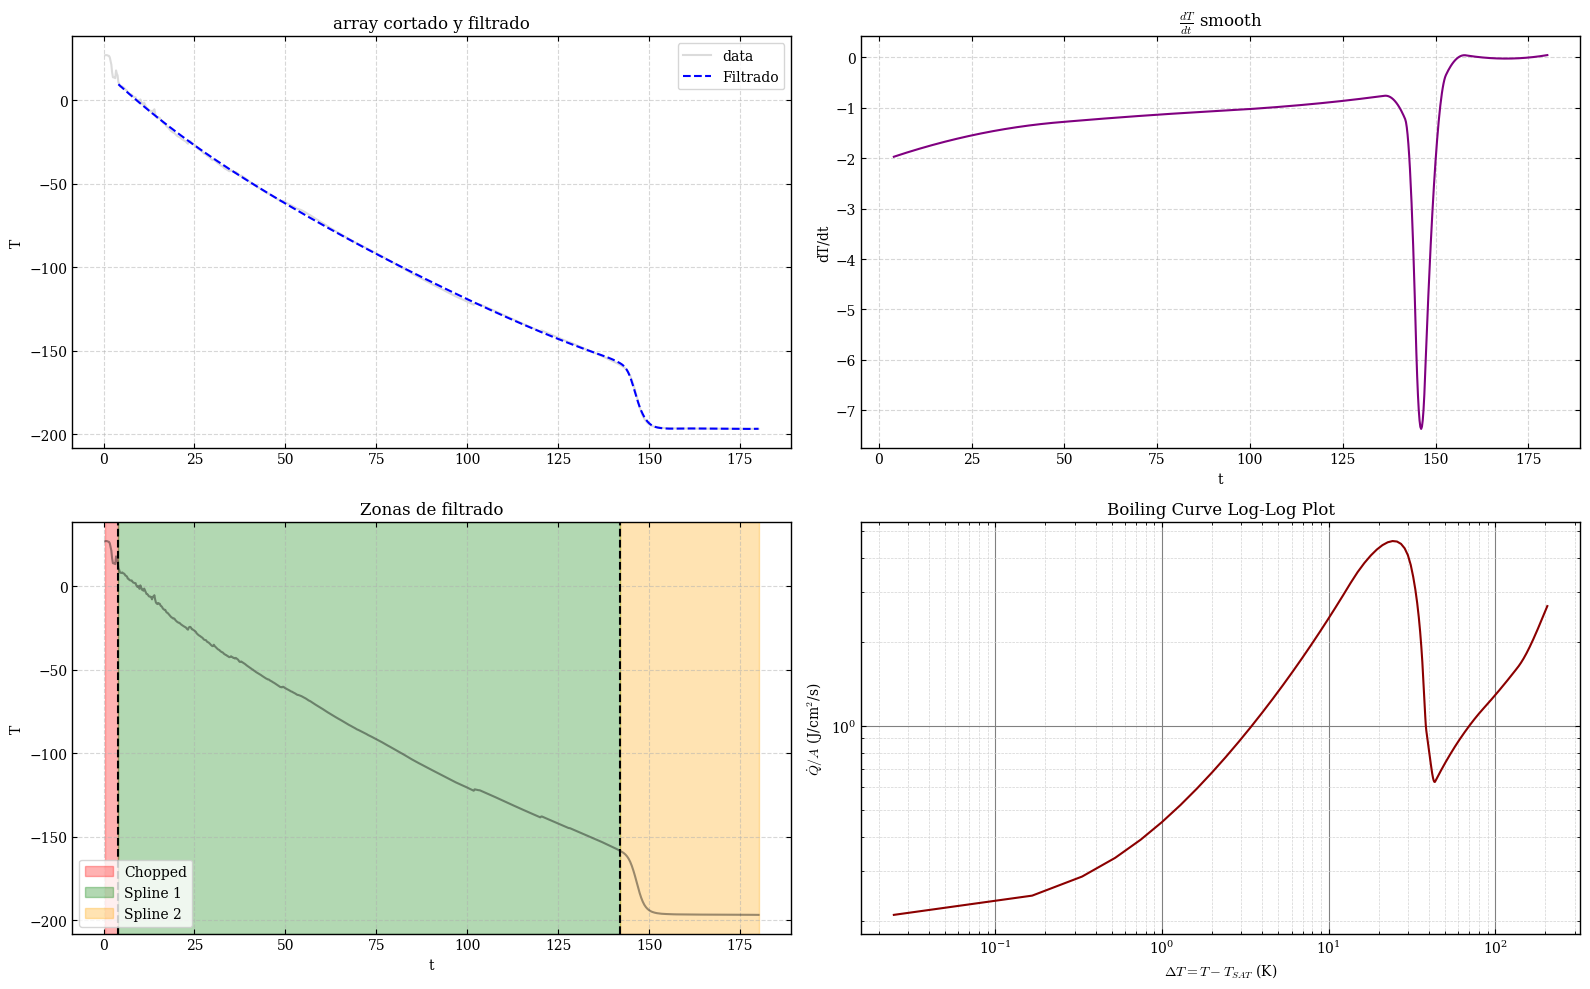

In [30]:
chop_t1 = 4.0
split_t1 = 142.0

t1_final, T1_final, dT1_dt, i_chop, i_split = apply_piecewise_spline(
    t1, T1, chop_time=chop_t1, split_time=split_t1,
    s1=500, s2=10, global_s=20  
)

DeltaT1, Q_dot_A_1 = boiling_curve(t1_final, T1_final, dT1_dt, mass_g=99.8, area_cm2=60.7, material='al')

plot_comprehensive_analysis(t1, T1, t1_final, T1_final, i_chop, i_split, chop_t1, split_t1, DeltaT1, Q_dot_A_1, dT1_dt)

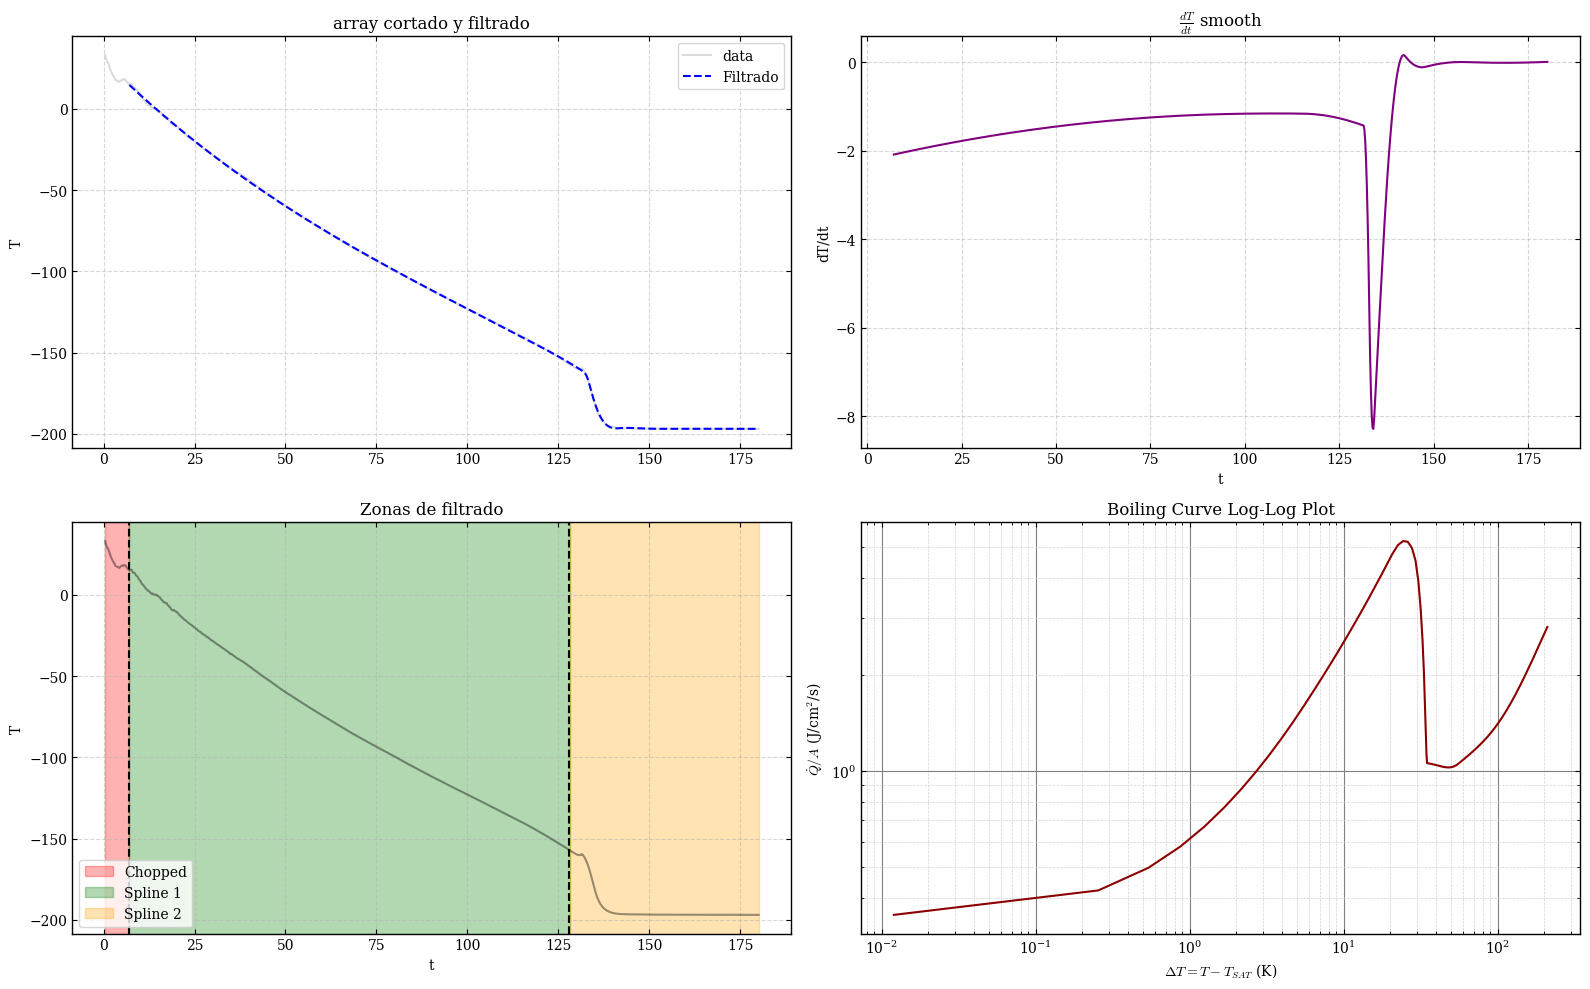

In [31]:
chop_t2 = 7.0
split_t2 = 128.0

t2_final, T2_final, dT2_dt, i_chop, i_split = apply_piecewise_spline(
    t2, T2, chop_time=chop_t2, split_time=split_t2,
    s1=500, s2=10, global_s=20  
)

DeltaT2, Q_dot_A_2 = boiling_curve(t2_final, T2_final, dT2_dt, mass_g=99, area_cm2=60.7, material='al')

plot_comprehensive_analysis(t2, T2, t2_final, T2_final, i_chop, i_split, chop_t2, split_t2, DeltaT2, Q_dot_A_2, dT2_dt)

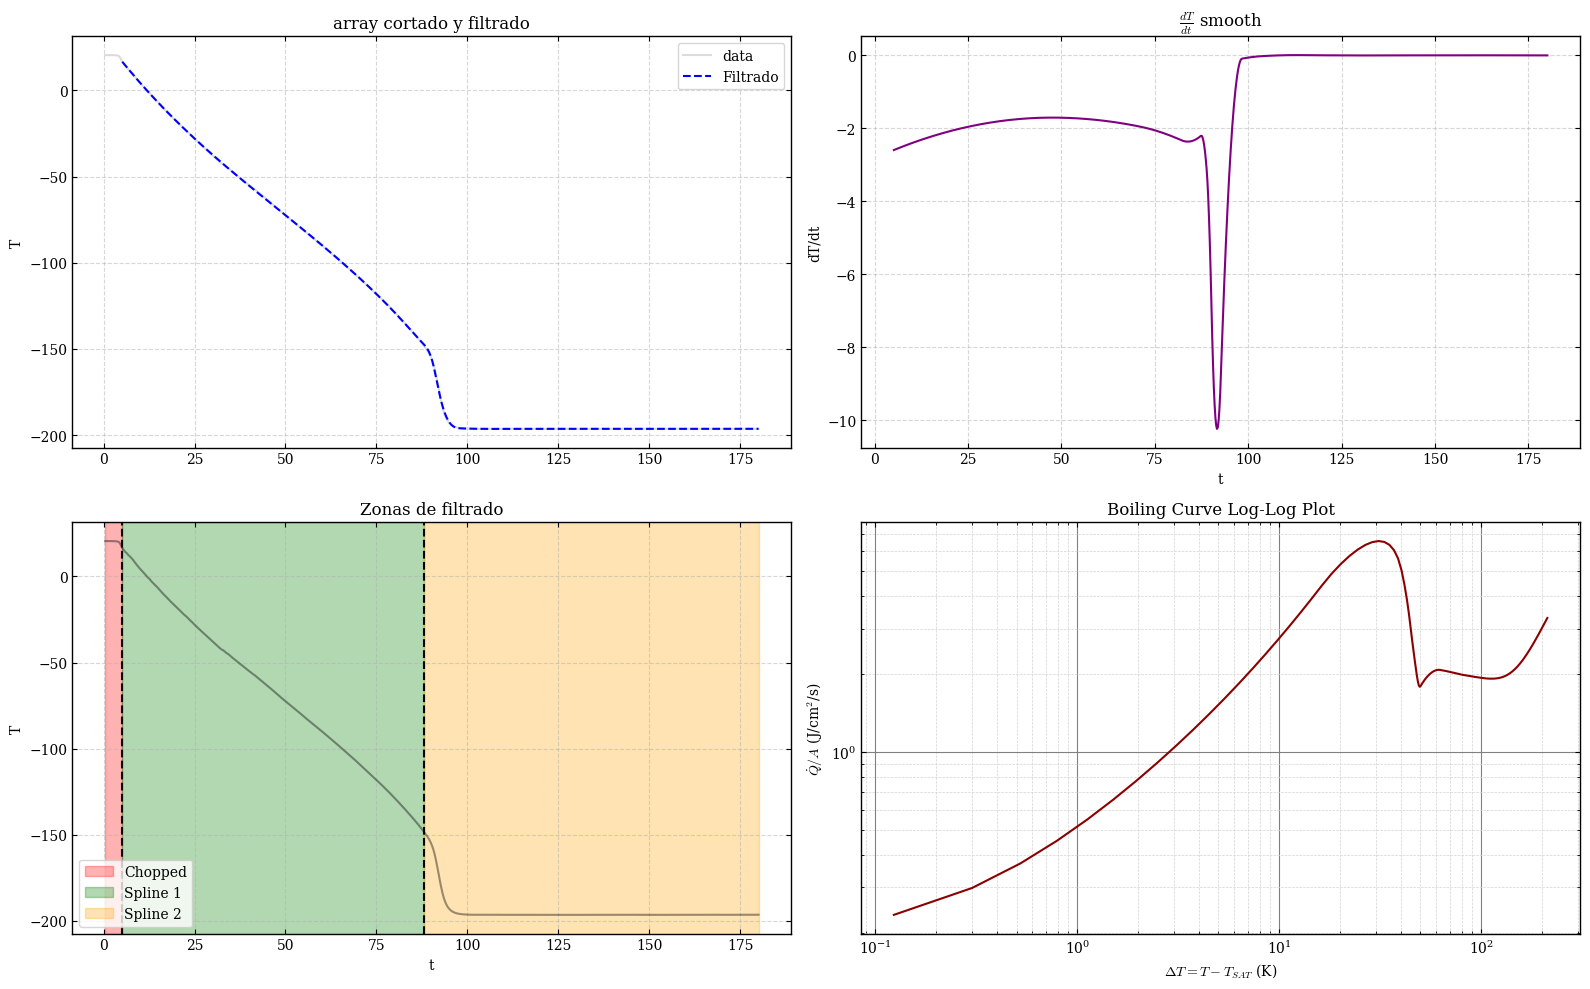

In [32]:
chop_t3 = 5.0
split_t3 = 88

t3_final, T3_final, dT3_dt, i_chop, i_split = apply_piecewise_spline(
    t3, T3, chop_time=chop_t3, split_time=split_t3,
    s1=500, s2=10, global_s=20  
)

DeltaT3, Q_dot_A_3 = boiling_curve(t3_final, T3_final, dT3_dt, mass_g=93, area_cm2=60.7, material='al')

plot_comprehensive_analysis(t3, T3, t3_final, T3_final, i_chop, i_split, chop_t3, split_t3, DeltaT3, Q_dot_A_3, dT3_dt)

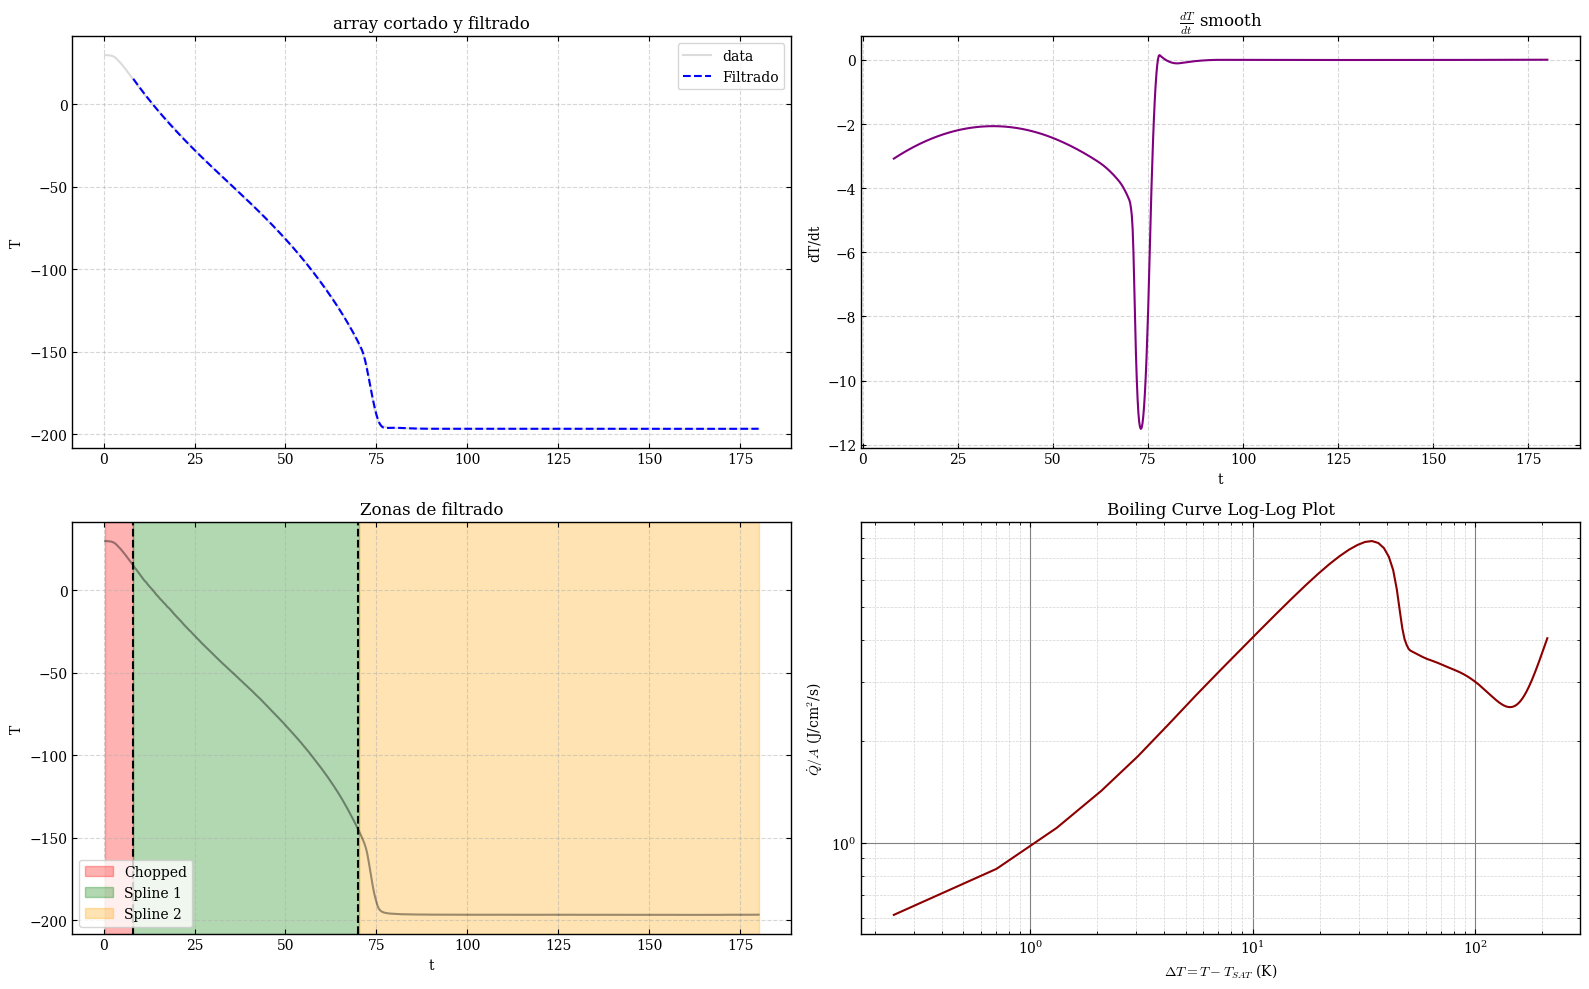

In [33]:
chop_t4 = 8.0
split_t4 = 70.0

t4_final, T4_final, dT4_dt, i_chop, i_split = apply_piecewise_spline(
    t4, T4, chop_time=chop_t4, split_time=split_t4,
    s1=500, s2=10, global_s=20  
)

DeltaT4, Q_dot_A_4 = boiling_curve(t4_final, T4_final, dT4_dt, mass_g=96, area_cm2=60.7, material='al')

plot_comprehensive_analysis(t4, T4, t4_final, T4_final, i_chop, i_split, chop_t4, split_t4, DeltaT4, Q_dot_A_4, dT4_dt)

<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_157106/2713324797.py:14: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel(' $\Delta T$ (°K)', fontsize=12)
/tmp/ipykernel_157106/2713324797.py:15: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('Flujo de Calor, $\dot{Q}_A$ (W/cm$^2$)', fontsize=12)


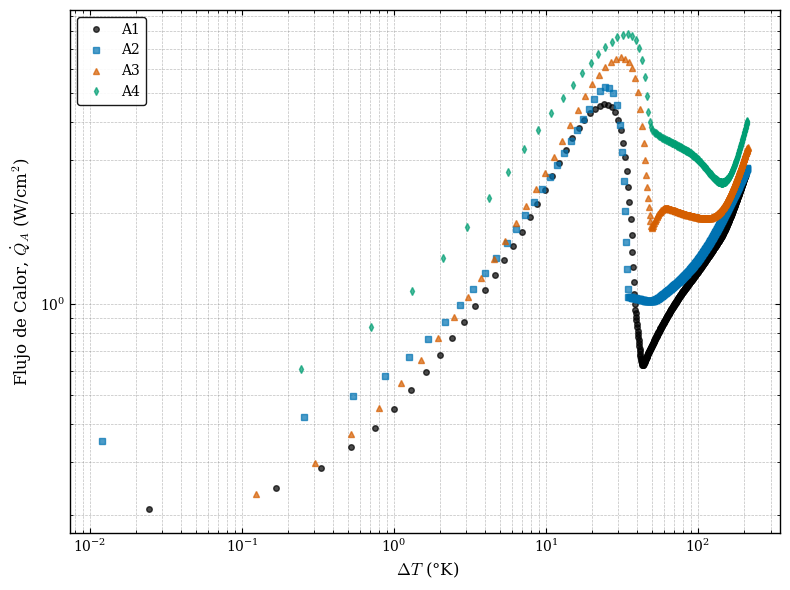

In [34]:
# Estilo profesional de figura
plt.figure(figsize=(8, 6), facecolor='white')
ax = plt.gca()

colors = ['#000000', '#0072B2', '#D55E00', '#009E73']

plt.loglog(DeltaT1, Q_dot_A_1, label='A1', marker='o', linestyle='', markersize=4, color=colors[0], alpha=0.7)
plt.loglog(DeltaT2, Q_dot_A_2, label='A2', marker='s', linestyle='', markersize=4, color=colors[1], alpha=0.7)
plt.loglog(DeltaT3, Q_dot_A_3, label='A3', marker='^', linestyle='', markersize=4, color=colors[2], alpha=0.7)
plt.loglog(DeltaT4, Q_dot_A_4, label='A4', marker='d', linestyle='', markersize=4, color=colors[3], alpha=0.7)

plt.grid(True, which="both", ls="--", color='gray', linewidth=0.5, alpha=0.5)

plt.xlabel(' $\Delta T$ (°K)', fontsize=12)
plt.ylabel('Flujo de Calor, $\dot{Q}_A$ (W/cm$^2$)', fontsize=12)

plt.legend(loc='upper left', fontsize=10, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_157106/894029545.py:15: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_xlabel('Temperatura de Exceso, $\Delta T$ (°K)', fontsize=12)
/tmp/ipykernel_157106/894029545.py:16: SyntaxWarning: invalid escape sequence '\d'
  ax1.set_ylabel('Flujo de Calor, $\dot{Q}_A$ (W/cm$^2$)', fontsize=12)


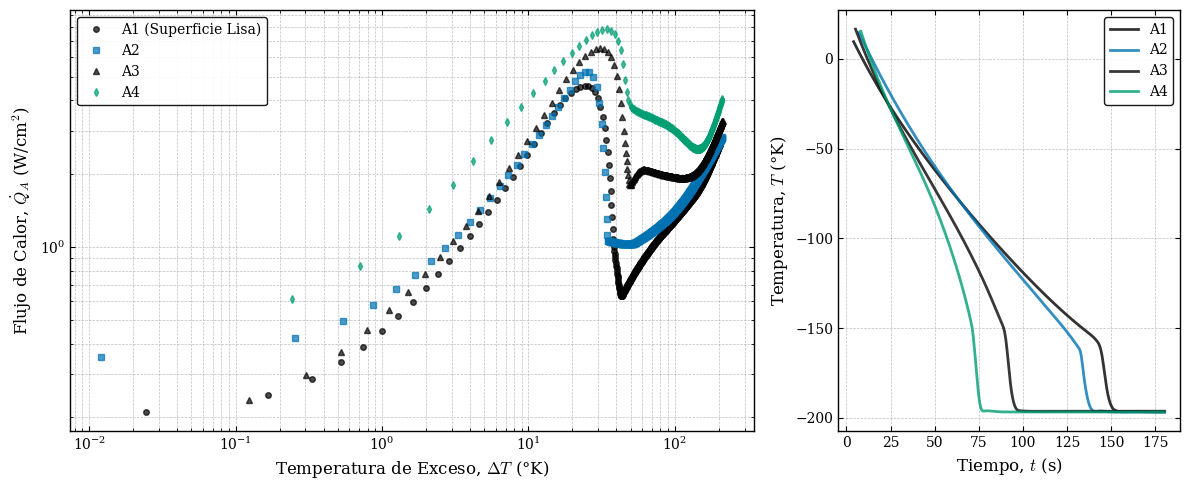

In [35]:
import matplotlib.pyplot as plt

# Crear figura con dos subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), facecolor='white', gridspec_kw={'width_ratios': [2, 1]})


colors = ['#000000', '#0072B2', "#070606", '#009E73']

ax1.loglog(DeltaT1, Q_dot_A_1, label='A1 (Superficie Lisa)', marker='o', linestyle='', markersize=4, color=colors[0], alpha=0.7)
ax1.loglog(DeltaT2, Q_dot_A_2, label='A2', marker='s', linestyle='', markersize=4, color=colors[1], alpha=0.7)
ax1.loglog(DeltaT3, Q_dot_A_3, label='A3', marker='^', linestyle='', markersize=4, color=colors[2], alpha=0.7)
ax1.loglog(DeltaT4, Q_dot_A_4, label='A4', marker='d', linestyle='', markersize=4, color=colors[3], alpha=0.7)

ax1.grid(True, which="both", ls="--", color='gray', linewidth=0.5, alpha=0.5)
ax1.set_xlabel('Temperatura de Exceso, $\Delta T$ (°K)', fontsize=12)
ax1.set_ylabel('Flujo de Calor, $\dot{Q}_A$ (W/cm$^2$)', fontsize=12)
ax1.legend(loc='upper left', fontsize=10, framealpha=0.9, edgecolor='black')

ax2.plot(t1_final, T1_final, label='A1', color=colors[0], linewidth=2, alpha=0.8)
ax2.plot(t2_final, T2_final, label='A2', color=colors[1], linewidth=2, alpha=0.8)
ax2.plot(t3_final, T3_final, label='A3', color=colors[2], linewidth=2, alpha=0.8)
ax2.plot(t4_final, T4_final, label='A4', color=colors[3], linewidth=2, alpha=0.8)

ax2.grid(True, which="major", ls="--", color='gray', linewidth=0.5, alpha=0.5)
ax2.set_xlabel('Tiempo, $t$ (s)', fontsize=12)
ax2.set_ylabel('Temperatura, $T$ (°K)', fontsize=12)
ax2.legend(loc='upper right', fontsize=10, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.savefig('comparative_boiling_curves.pdf', dpi=300)  # Guardar la figura con alta resolución
plt.show()

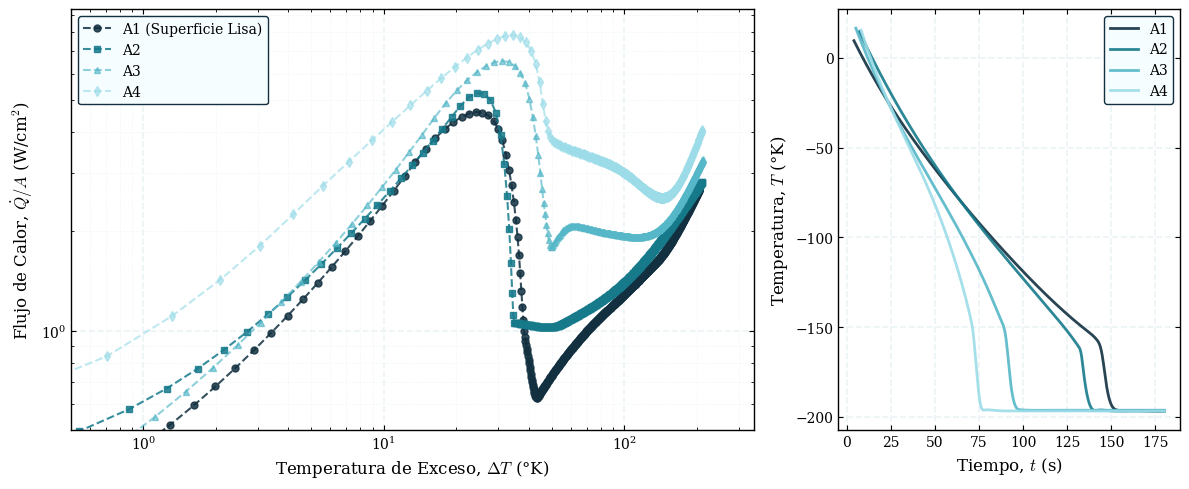

In [36]:

# Configuración global para igualar la estética de gaston 
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm', 
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.0,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), facecolor='white', gridspec_kw={'width_ratios': [2, 1]})

colors = ['#123040', '#167A8B', '#55B7C8', '#9BDCE8']
bg_color = '#F6FDFF'    
grid_color = '#EAF3F5'  

ax1.loglog(DeltaT1, Q_dot_A_1, marker='o', linestyle='--', markersize=5, color=colors[0], alpha=0.85,label='A1 (Superficie Lisa)')
ax1.loglog(DeltaT2, Q_dot_A_2, marker='s', linestyle='--', markersize=5, color=colors[1], alpha=0.85,label='A2')
ax1.loglog(DeltaT3, Q_dot_A_3, marker='^', linestyle='--', markersize=5, color=colors[2], alpha=0.65,label='A3')
ax1.loglog(DeltaT4, Q_dot_A_4, marker='d', linestyle='--', markersize=5, color=colors[3], alpha=0.65,label='A4')

# Cortar el eje X para que arranque en 10^0
ax1.set_xlim(left=0.5)
ax1.set_ylim(bottom=0.5)


ax1.grid(True, which="major", ls="--", color=grid_color, linewidth=1.2)
ax1.grid(True, which="minor", ls=":", color=grid_color, linewidth=0.6)

ax1.set_xlabel(r'Temperatura de Exceso, $\Delta T$ (°K)', fontsize=12)
ax1.set_ylabel(r'Flujo de Calor, $\dot{Q}/A$ (W/cm$^2$)', fontsize=12)
ax1.legend(loc='upper left', fontsize=10, framealpha=1, edgecolor=colors[0], facecolor=bg_color)

ax2.plot(t1_final, T1_final, label='A1', color=colors[0], linewidth=2, alpha=0.9)
ax2.plot(t2_final, T2_final, label='A2', color=colors[1], linewidth=2, alpha=0.9)
ax2.plot(t3_final, T3_final, label='A3', color=colors[2], linewidth=2, alpha=0.9)
ax2.plot(t4_final, T4_final, label='A4', color=colors[3], linewidth=2, alpha=0.9)

ax2.grid(True, which="major", ls="--", color=grid_color, linewidth=1.2)
ax2.set_xlabel(r'Tiempo, $t$ (s)', fontsize=12)
ax2.set_ylabel(r'Temperatura, $T$ (°K)', fontsize=12)
ax2.legend(loc='upper right', fontsize=10, framealpha=1, edgecolor=colors[0], facecolor=bg_color)

plt.tight_layout()
plt.savefig('comparative_boiling_curves.pdf', dpi=300, bbox_inches='tight') 
plt.show()

# Cobre vs aluminio

In [16]:
dfcu=pd.read_csv('data_clean/C0.csv')
dfal=pd.read_csv('data_clean/A0.csv')

tcu,Tcu,Wcu = dfcu['t'].values, dfcu['T'].values, dfcu['W'].values
tal,Tal,Wal = dfal['t'].values, dfal['T'].values, dfal['W'].values

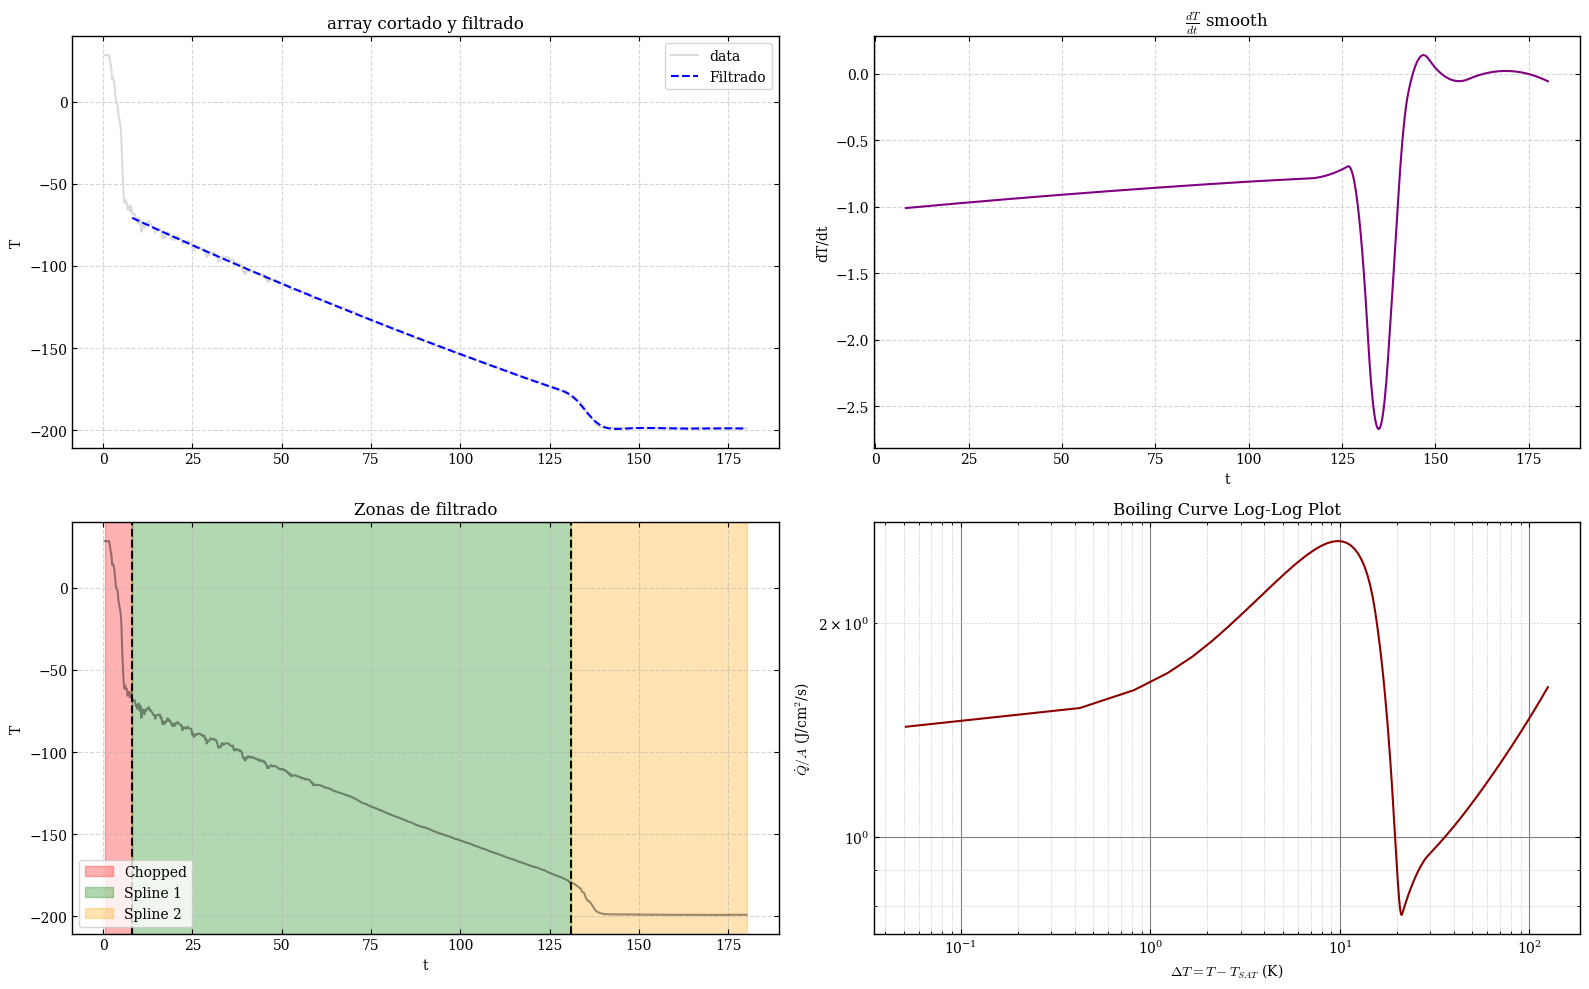

In [17]:
chop_tcu = 8.0
split_tcu = 131.0

tcu_final, Tcu_final, dTcu_dt, i_chop, i_split = apply_piecewise_spline(
    tcu, Tcu, chop_time=chop_tcu, split_time=split_tcu,
    s1=700, s2=10, global_s=20  
)

DeltaTcu, Q_dot_A_cu = boiling_curve(tcu_final, Tcu_final, dTcu_dt, mass_g=165, area_cm2=35.8, material='cu')

plot_comprehensive_analysis(tcu, Tcu, tcu_final, Tcu_final, i_chop, i_split, chop_tcu, split_tcu, DeltaTcu, Q_dot_A_cu, dTcu_dt)

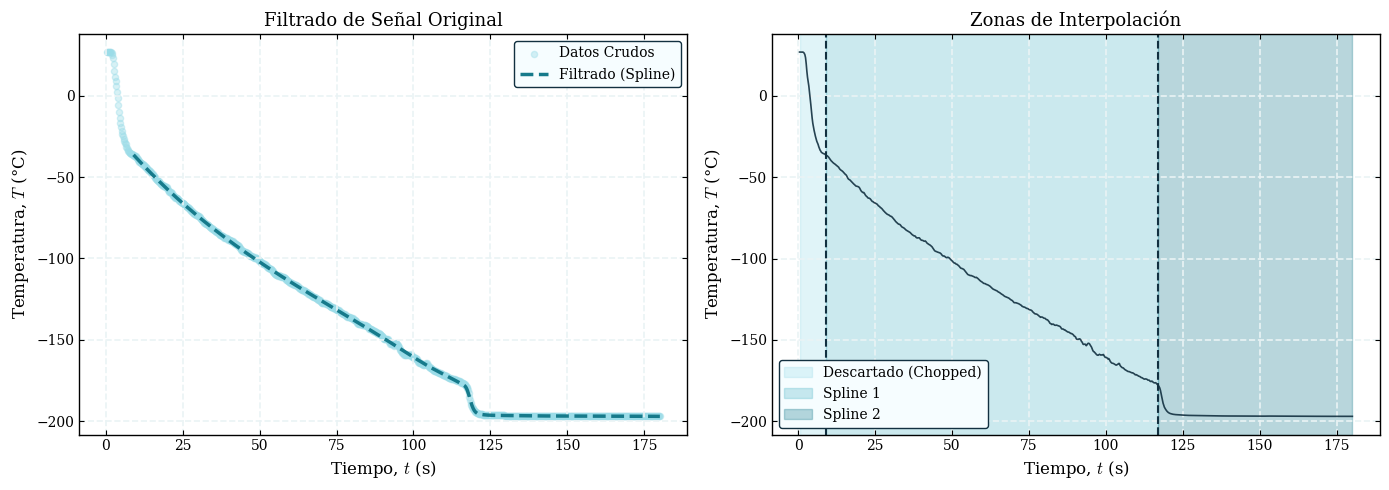

In [18]:
# --- 1. Global Aesthetic Setup ---
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm', 
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.0,
})

colors = ['#123040', '#167A8B', '#55B7C8', '#9BDCE8']
bg_color = '#F6FDFF'    
grid_color = '#EAF3F5'  

# --- 2. Data Processing (Your Spline Logic) ---
chop_tal = 9.0
split_tal = 117.0

def apply_piecewise_spline(t, T, chop_time, split_time, s1, s2, global_s, k=3):
    idx_chop = np.searchsorted(t, chop_time)
    idx_split = np.searchsorted(t, split_time)
    
    t_seg1, T_seg1 = t[idx_chop:idx_split], T[idx_chop:idx_split]
    t_seg2, T_seg2 = t[idx_split:], T[idx_split:]
    
    spline1 = UnivariateSpline(t_seg1, T_seg1, k=k, s=s1)
    spline2 = UnivariateSpline(t_seg2, T_seg2, k=k, s=s2)
    
    T_seg1_filt = spline1(t_seg1)
    T_seg2_filt = spline2(t_seg2)
    
    t_final = np.concatenate((t_seg1, t_seg2))
    T_final = np.concatenate((T_seg1_filt, T_seg2_filt))
    
    if global_s:
        global_spline = UnivariateSpline(t_final, T_final, k=k, s=global_s)
        T_final = global_spline(t_final)
        
    return t_final, T_final, idx_chop, idx_split

# Apply the function
tal_final, Tal_final, i_chop, i_split = apply_piecewise_spline(
    tal, Tal, chop_time=chop_tal, split_time=split_tal,
    s1=200, s2=10, global_s=20  
)

# --- 3. The 1x2 Plotting Code ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# --- Left Plot: Raw vs Filtered ---
# Raw data is now darker and more opaque to highlight the noise
ax1.scatter(tal, Tal, color=colors[3], label='Datos Crudos', alpha=0.4,s=20)
# The filtered line is thick and uses the dominant ice color
ax1.plot(tal_final, Tal_final, color=colors[1], label='Filtrado (Spline)', linewidth=2.5,linestyle='--')

ax1.set_xlabel('Tiempo, $t$ (s)', fontsize=12)
ax1.set_ylabel('Temperatura, $T$ (°C)', fontsize=12)
ax1.set_title('Filtrado de Señal Original', fontsize=13)
ax1.grid(True, which="major", ls="--", color=grid_color, linewidth=1.2)
ax1.legend(loc='upper right', fontsize=10, framealpha=1, edgecolor=colors[0], facecolor=bg_color)

# --- Right Plot: Segmentation Zones ---
# Background noisy data
ax2.plot(tal, Tal, color=colors[0], alpha=0.9, linewidth=1.2)

# Ice-themed transition zones instead of red/green/orange
ax2.axvspan(tal[0], tal[i_chop], color=colors[3], alpha=0.3, label='Descartado (Chopped)')
ax2.axvspan(tal[i_chop], tal[i_split], color=colors[2], alpha=0.3, label='Spline 1')
ax2.axvspan(tal[i_split], tal[-1], color=colors[1], alpha=0.3, label='Spline 2')

# Dashed boundary lines
ax2.axvline(x=chop_tal, color=colors[0], linestyle='--', linewidth=1.5)
ax2.axvline(x=split_tal, color=colors[0], linestyle='--', linewidth=1.5)

ax2.set_xlabel('Tiempo, $t$ (s)', fontsize=12)
ax2.set_ylabel('Temperatura, $T$ (°C)', fontsize=12)
ax2.set_title('Zonas de Interpolación', fontsize=13)
ax2.grid(True, which="major", ls="--", color=grid_color, linewidth=1.2)
ax2.legend(loc='lower left', fontsize=10, framealpha=1, edgecolor=colors[0], facecolor=bg_color)

plt.tight_layout()
plt.savefig('filtering_process.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
chop_tal = 9.0
split_tal = 117.0

tal_final, Tal_final, dTal_dt, i_chop, i_split = apply_piecewise_spline(
    tal, Tal, chop_time=chop_tal, split_time=split_tal,
    s1=700, s2=10, global_s=20  
)

DeltaTal, Q_dot_A_al = boiling_curve(tal_final, Tal_final, dTal_dt, mass_g=66, area_cm2=49.5, material='al')

plot_comprehensive_analysis(tal, Tal, tal_final, Tal_final, i_chop, i_split, chop_tal, split_tal, DeltaTal, Q_dot_A_al, dTal_dt)

ValueError: not enough values to unpack (expected 5, got 4)

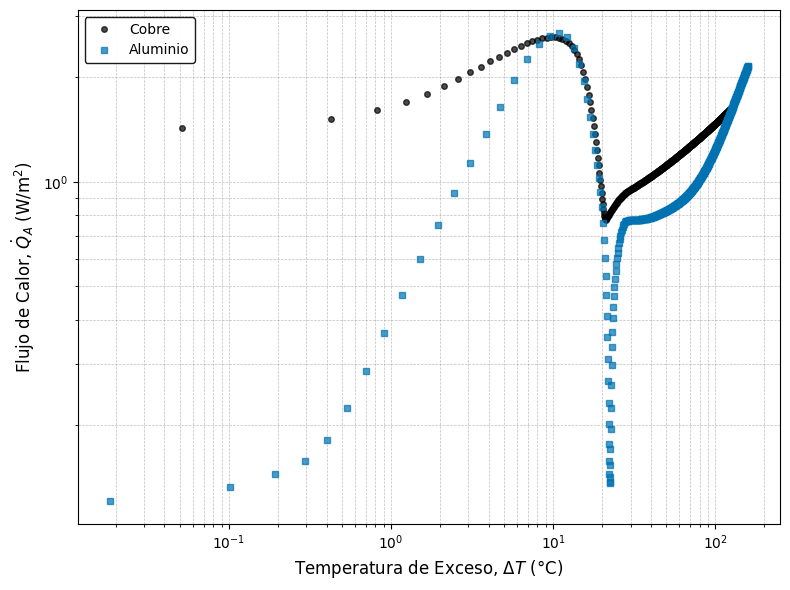

In [ ]:
#Comparacion cobre y aluminio

plt.figure(figsize=(8, 6), facecolor='white')
colors = ['#000000', '#0072B2']  #
plt.loglog(DeltaTcu, Q_dot_A_cu, label='Cobre', marker='o', linestyle='', markersize=4, color=colors[0], alpha=0.7)
plt.loglog(DeltaTal, Q_dot_A_al, label='Aluminio', marker
='s', linestyle='', markersize=4, color=colors[1], alpha=0.7)
plt.grid(True, which="both", ls="--", color='gray', linewidth=0.5, alpha=0.5)
plt.xlabel('Temperatura de Exceso, $\Delta T$ (°C)', fontsize=12)
plt.ylabel('Flujo de Calor, $\dot{Q}_A$ (W/cm$^2$)', fontsize=12)
plt.legend(loc='upper left', fontsize=10, framealpha=0.9, edgecolor='black')
plt.tight_layout()


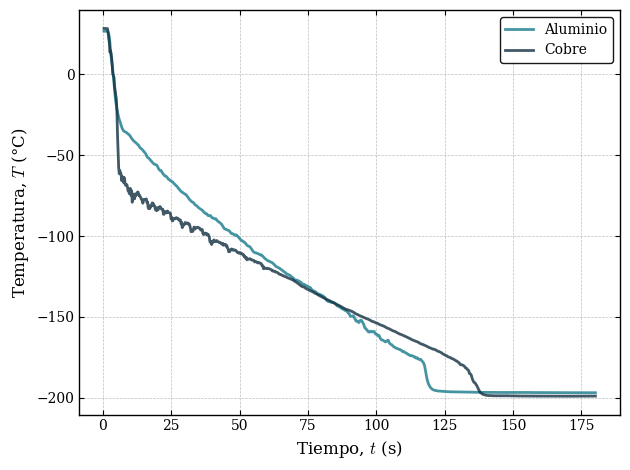

In [20]:
plt.plot(tal,Tal, label='Aluminio', color=colors[1], linewidth=2, alpha=0.8)
plt.plot(tcu,Tcu, label='Cobre', color=colors[0], linewidth=2, alpha=0.8)
plt.grid(True, which="major", ls="--", color='gray', linewidth=0.5, alpha=0.5)
plt.xlabel('Tiempo, $t$ (s)', fontsize=12)
plt.ylabel('Temperatura, $T$ (°C)', fontsize=12)
plt.legend(loc='upper right', fontsize=10, framealpha=0.9, edgecolor='black')
plt.tight_layout()